### **Étape 1 : Importation et Chargement**


In [156]:
# Importation des bibliothèques requises 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import statsmodels.api as sm
import warnings

In [157]:
# Configuration pour éviter les warnings inutiles
warnings.filterwarnings('ignore')

In [158]:
# Configuration de l'affichage pour seaborn
sns.set_theme(style="whitegrid")

# Chargement du fichier CSV 
df = pd.read_csv('heart_disease_uci.csv')

# Vérification des dimensions, des types et aperçu
print(f"Dimensions du dataset (lignes, colonnes) : {df.shape}")
print("\nTypes des variables :")
print(df.dtypes)

print("\nAperçu des 5 premières lignes :")
display(df.head())

print("\nInformations générales des 5 premières lignes  :")
df.head().info()

Dimensions du dataset (lignes, colonnes) : (920, 16)

Types des variables :
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Aperçu des 5 premières lignes :


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Informations générales des 5 premières lignes  :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        5 non-null      int64  
 1   age       5 non-null      int64  
 2   sex       5 non-null      object 
 3   dataset   5 non-null      object 
 4   cp        5 non-null      object 
 5   trestbps  5 non-null      float64
 6   chol      5 non-null      float64
 7   fbs       5 non-null      object 
 8   restecg   5 non-null      object 
 9   thalch    5 non-null      float64
 10  exang     5 non-null      object 
 11  oldpeak   5 non-null      float64
 12  slope     5 non-null      object 
 13  ca        5 non-null      float64
 14  thal      5 non-null      object 
 15  num       5 non-null      int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 772.0+ bytes


### **Étape 2 : Analyse Exploratoire des Données (EDA)**


In [160]:
# Statistiques descriptives 
print("\nStatistiques descriptives (variables numériques) :")
display(df.describe())

print("\nStatistiques descriptives (variables catégorielles) :")
display(df.describe(include=['object', 'bool']))


Statistiques descriptives (variables numériques) :


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000



Statistiques descriptives (variables catégorielles) :


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


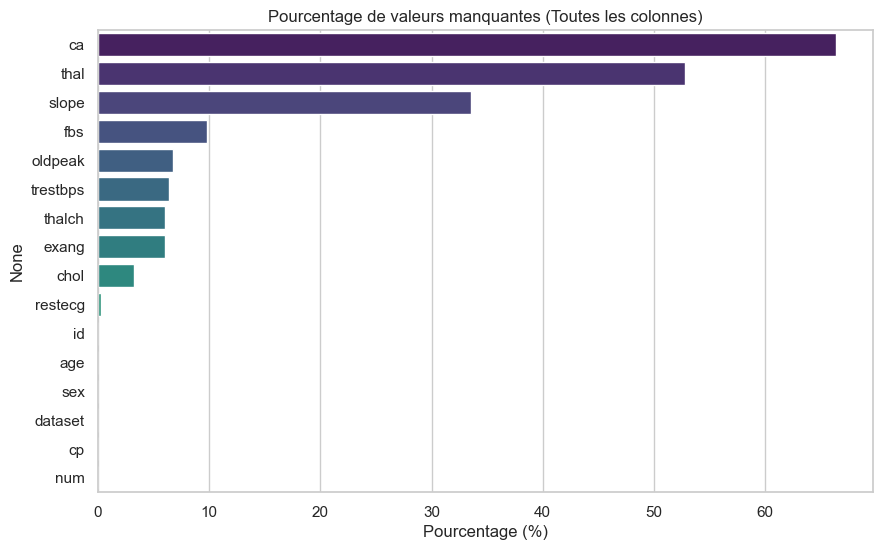

In [161]:
# Analyse des valeurs manquantes

# Calculer le nombre et le pourcentage de valeurs manquantes par colonne
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Valeurs manquantes': missing_data, 'Pourcentage (%)': missing_percent})
missing_df = missing_df.sort_values(by='Pourcentage (%)', ascending=False)
# Visualiser avec un barplot horizontal
plt.figure(figsize=(10, 6))
sns.barplot(x='Pourcentage (%)', y=missing_df.index, data=missing_df, palette='viridis')
plt.title("Pourcentage de valeurs manquantes (Toutes les colonnes)")
plt.show()

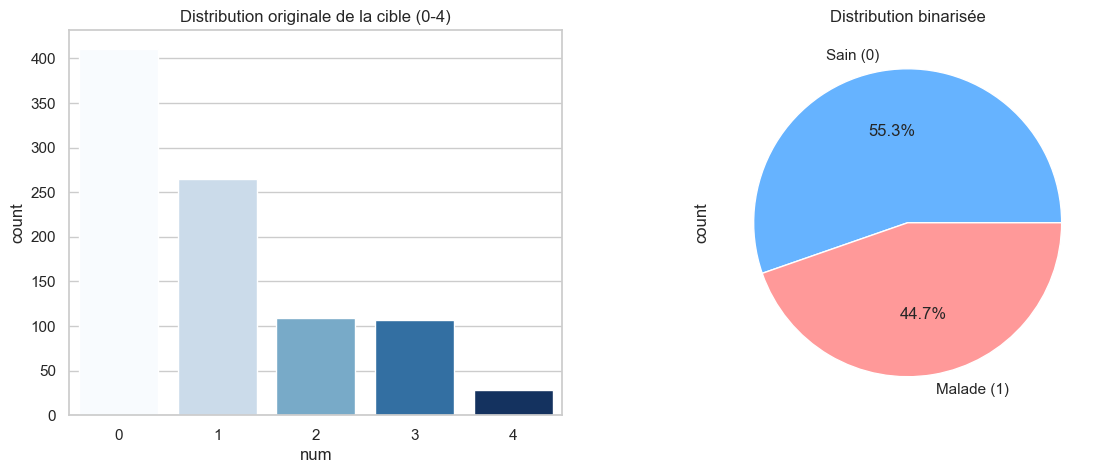

In [162]:
# Distribution de la variable cible

# Création de la variable cible binarisée (0 = sain, 1 = malade)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='num', hue='num', ax=axes[0], palette='Blues', legend=False)
axes[0].set_title("Distribution originale de la cible (0-4)")

df['target'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', labels=['Sain (0)', 'Malade (1)'], colors=['#66b3ff','#ff9999'])
axes[1].set_title("Distribution binarisée")
plt.show()


*ce dataset présente environ 55% de cas sains et 45% de cas malades, ce qui est considéré comme **un dataset relativement équilibré**.*

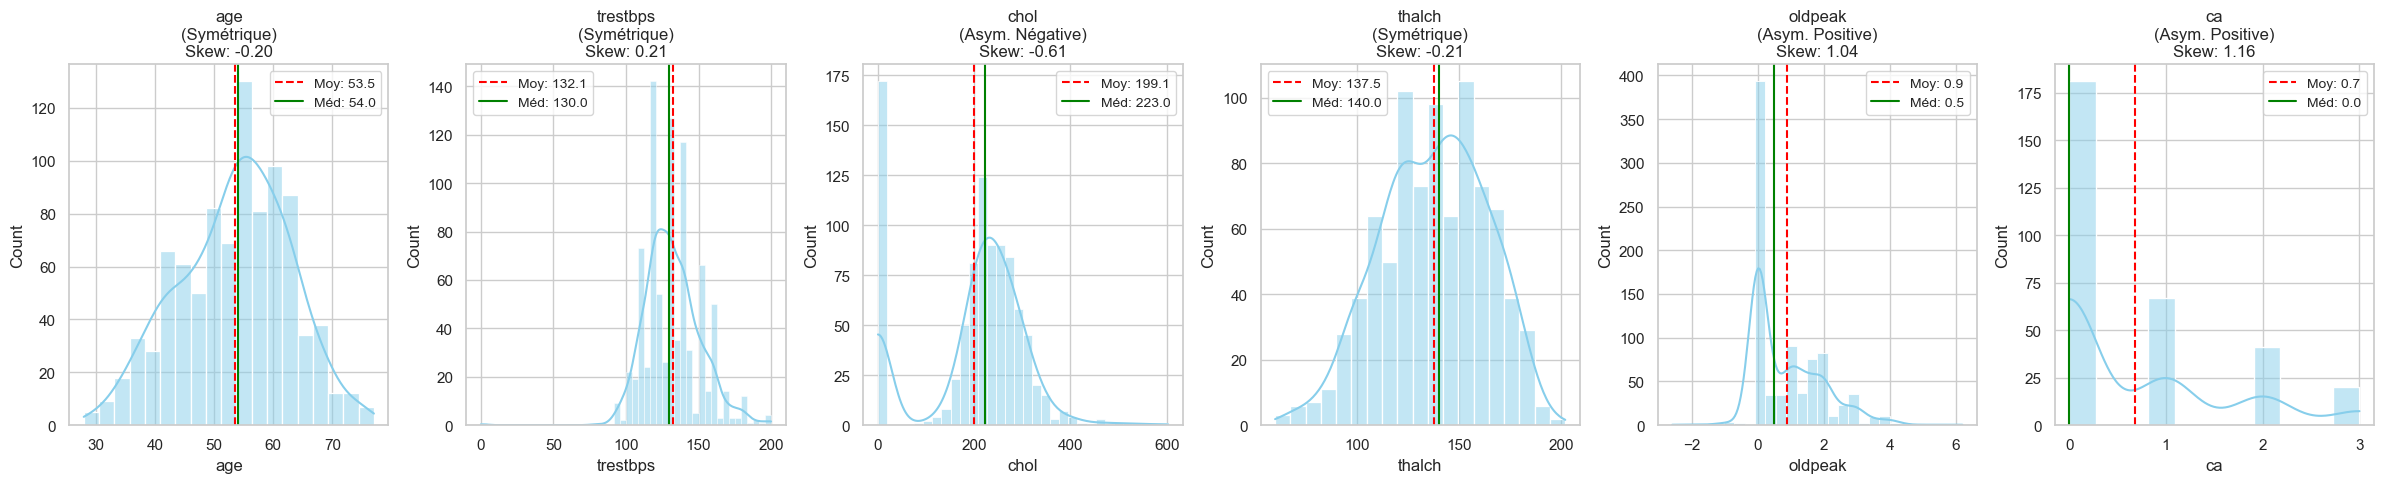

In [164]:
# Variables numériques
from scipy.stats import skew

num_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
fig, axes = plt.subplots(1, 6, figsize=(24, 5))

for i, col in enumerate(num_vars):
    # Calcul des statistiques
    mean_val = df[col].mean()
    median_val = df[col].median()
    skewness = skew(df[col].dropna()) # Calcul de l'asymétrie
    
    # Histogramme et KDE
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    
    # Ajout des lignes verticales
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Moy: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Méd: {median_val:.1f}')
    
    # Identification de l'asymétrie dans le titre
    if skewness > 0.5:
        dist_type = "Asym. Positive"
    elif skewness < -0.5:
        dist_type = "Asym. Négative"
    else:
        dist_type = "Symétrique"
        
    axes[i].set_title(f"{col}\n({dist_type})\nSkew: {skewness:.2f}")
    axes[i].legend(fontsize='small')

plt.tight_layout()
plt.show()

**Analyse des résultats :**

*Lignes de tendance* : La ligne rouge (pointillée) représente la moyenne.

La ligne verte (continue) représente la médiane.

Note : Plus l`écart entre la ligne rouge et la ligne verte est grand, plus la distribution est asymétrique.

*Identification des distributions asymétriques :*

Asymétrie Positive (Skew > 0.5) : Généralement observée sur oldpeak et ca. La queue de la distribution s`étire vers la droite (les hautes valeurs). Cela signifie que la majorité des patients ont des valeurs faibles pour ces critères, avec quelques cas extrêmes.

Asymétrie Négative (Skew < -0.5) : Souvent observée sur thalch (fréquence cardiaque maximale). La queue s`étire vers la gauche, indiquant que la plupart des patients ont des fréquences cardiaques élevées.

Distribution Symétrique (Skew entre -0.5 et 0.5) : Les variables comme age ou trestbps (pression artérielle) tendent souvent vers une forme de cloche (distribution normale), où la moyenne et la médiane sont très proches.

**avec :$$Skew \approx \frac{3 \times (\text{Moyenne} - \text{Médiane})}{\text{Écart-type}}$$**

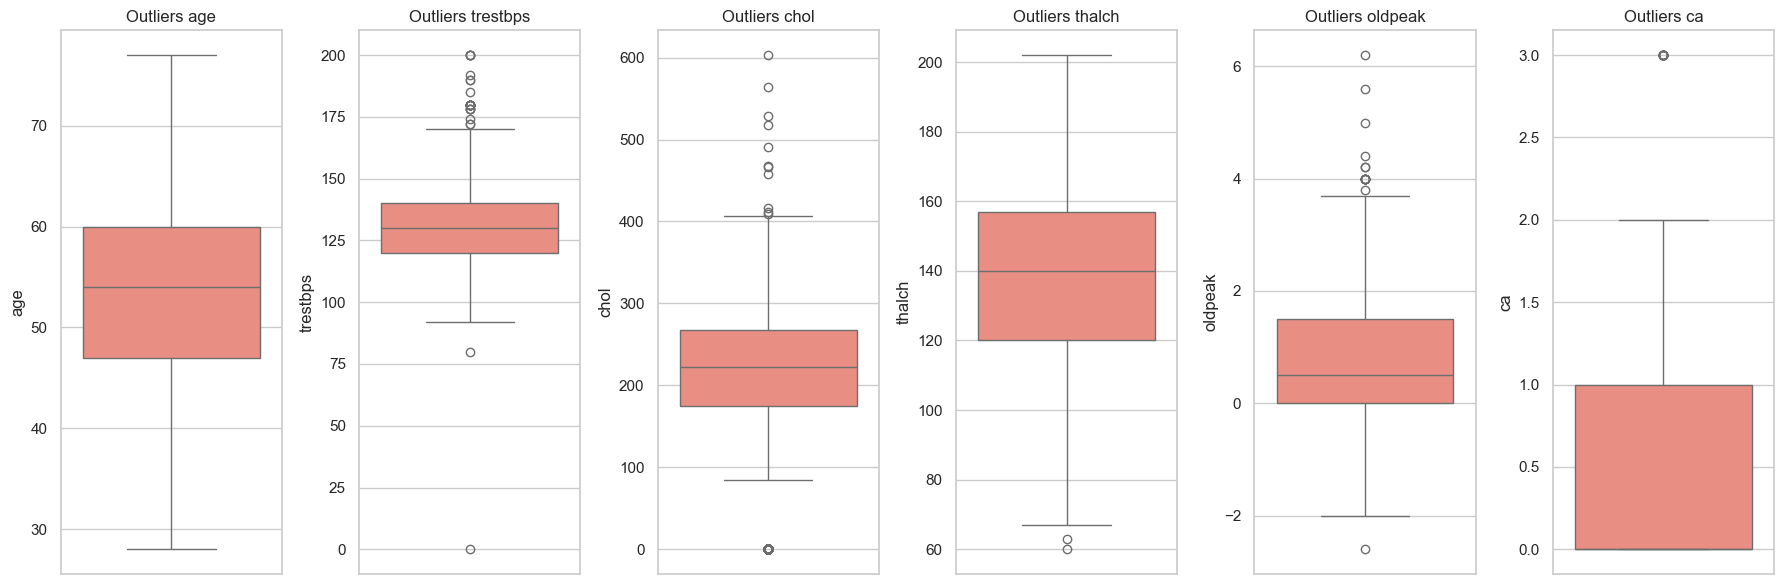

--- Analyse des valeurs extrêmes (IQR) ---
age : 0 outliers potentiels (Bornes: 27.5 - 79.5)
trestbps : 28 outliers potentiels (Bornes: 90.0 - 170.0)
chol : 183 outliers potentiels (Bornes: 35.5 - 407.5)
thalch : 2 outliers potentiels (Bornes: 64.5 - 212.5)
oldpeak : 16 outliers potentiels (Bornes: -2.2 - 3.8)
ca : 20 outliers potentiels (Bornes: -1.5 - 2.5)

--- Détection des valeurs aberrantes cliniques ---
Nombre de patients avec Cholestérol = 0 : 172
Nombre de patients avec Tension (trestbps) = 0 : 1


In [166]:
# Détection des outliers

# Boxplots pour chaque variable numérique
num_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
plt.figure(figsize=(18, 6))
for i, col in enumerate(num_vars):
    plt.subplot(1, 6, i+1)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f"Outliers {col}")
plt.tight_layout()
plt.show()

# Identifier les valeurs extrêmes (Méthode IQR)
print("--- Analyse des valeurs extrêmes (IQR) ---")
for col in num_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"{col} : {outliers_count} outliers potentiels (Bornes: {lower_bound:.1f} - {upper_bound:.1f})")

# 2.5.3 Repérer les valeurs aberrantes spécifiques 
print("\n--- Détection des valeurs aberrantes cliniques ---")
aberrant_chol = df[df['chol'] == 0].shape[0]
aberrant_trestbps = df[df['trestbps'] == 0].shape[0]

print(f"Nombre de patients avec Cholestérol = 0 : {aberrant_chol}")
print(f"Nombre de patients avec Tension (trestbps) = 0 : {aberrant_trestbps}")


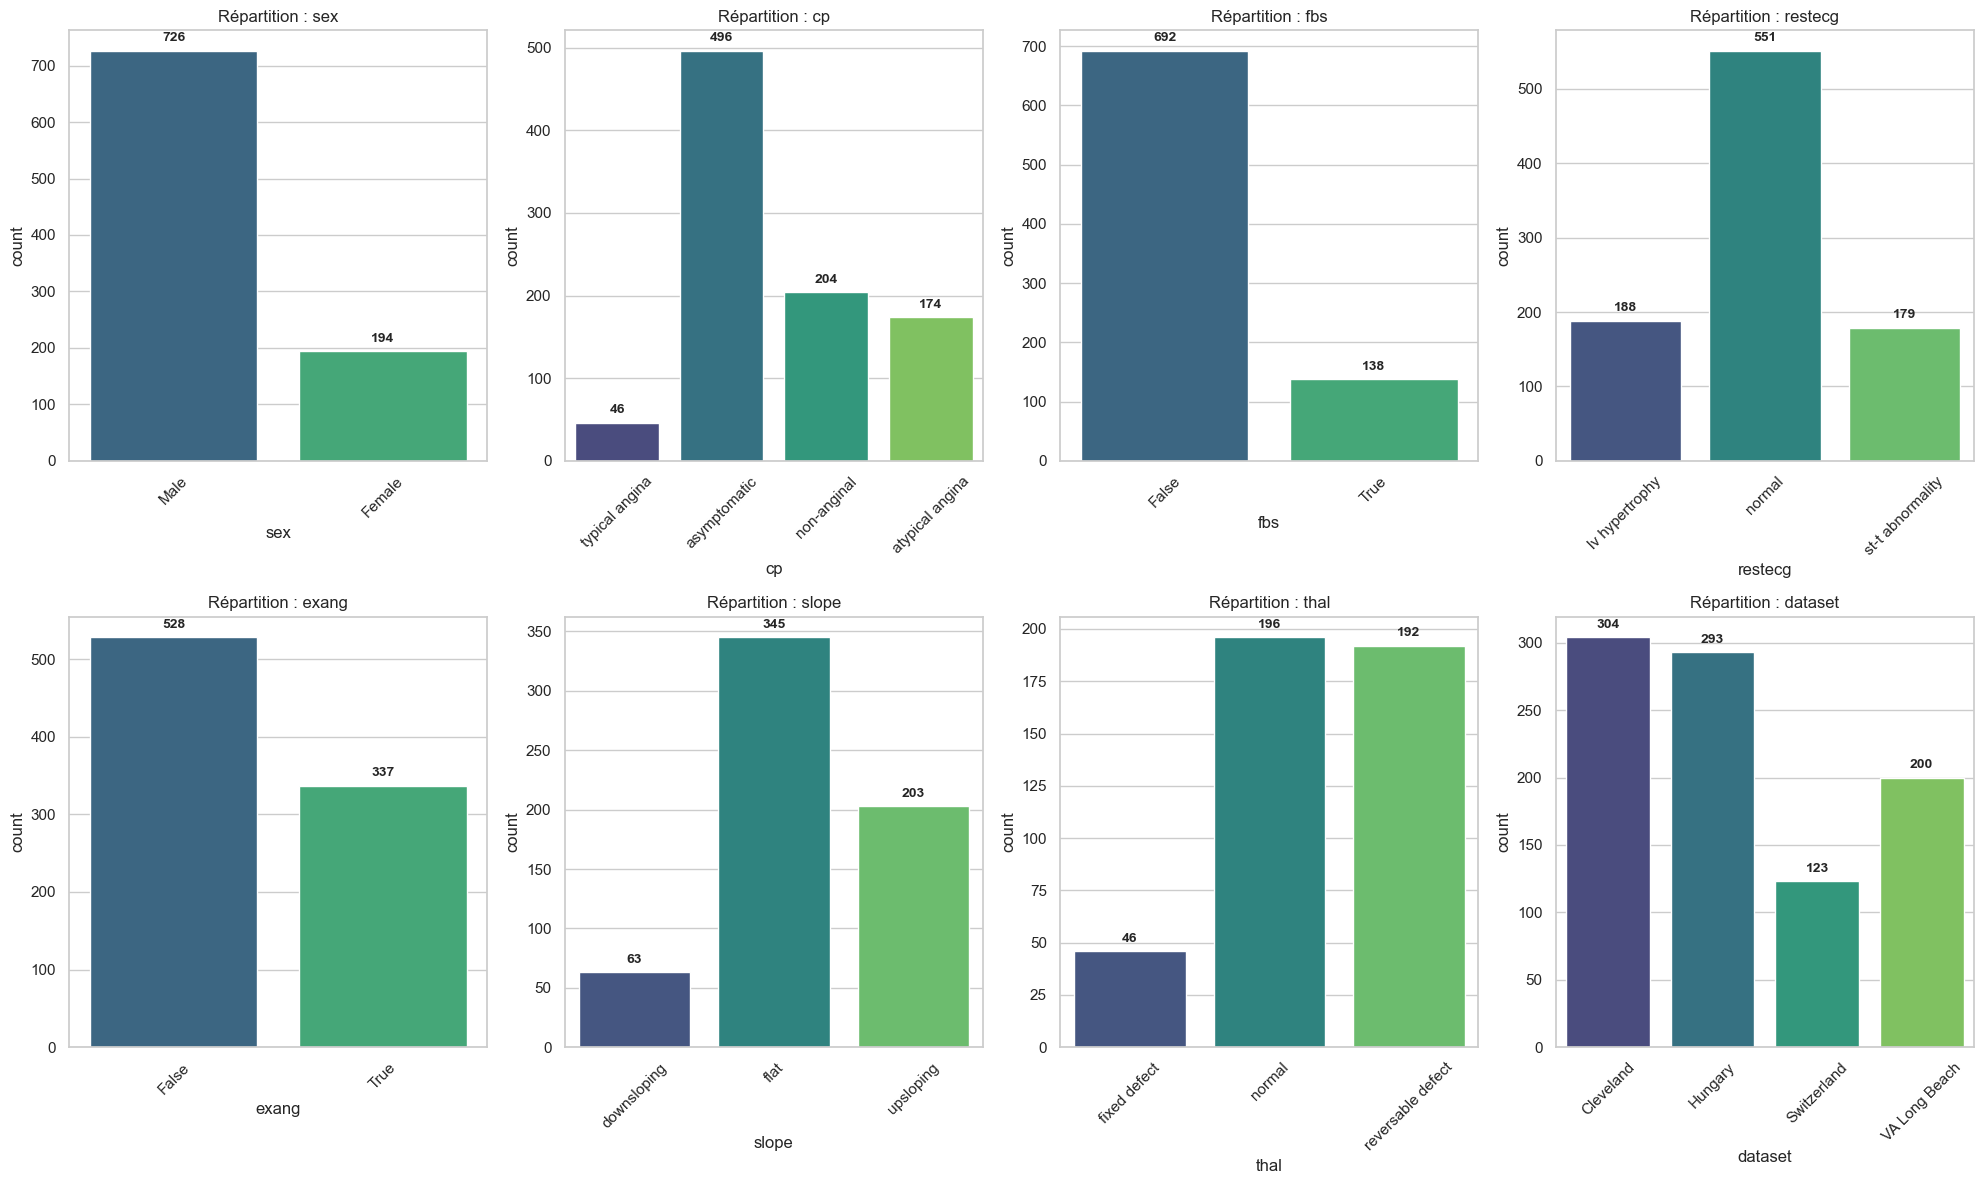

In [167]:
# Countplots pour les variables catégorielles
cat_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']

plt.figure(figsize=(20, 12))

for i, col in enumerate(cat_vars):
    plt.subplot(2, 4, i+1)
    ax = sns.countplot(x=df[col], palette='viridis', hue=df[col], legend=False)
    plt.title(f"Répartition : {col}")
    plt.xticks(rotation=45)
    
# Annoter les effectifs sur chaque barre
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10,
                    fontweight='bold')

plt.tight_layout()
plt.show()

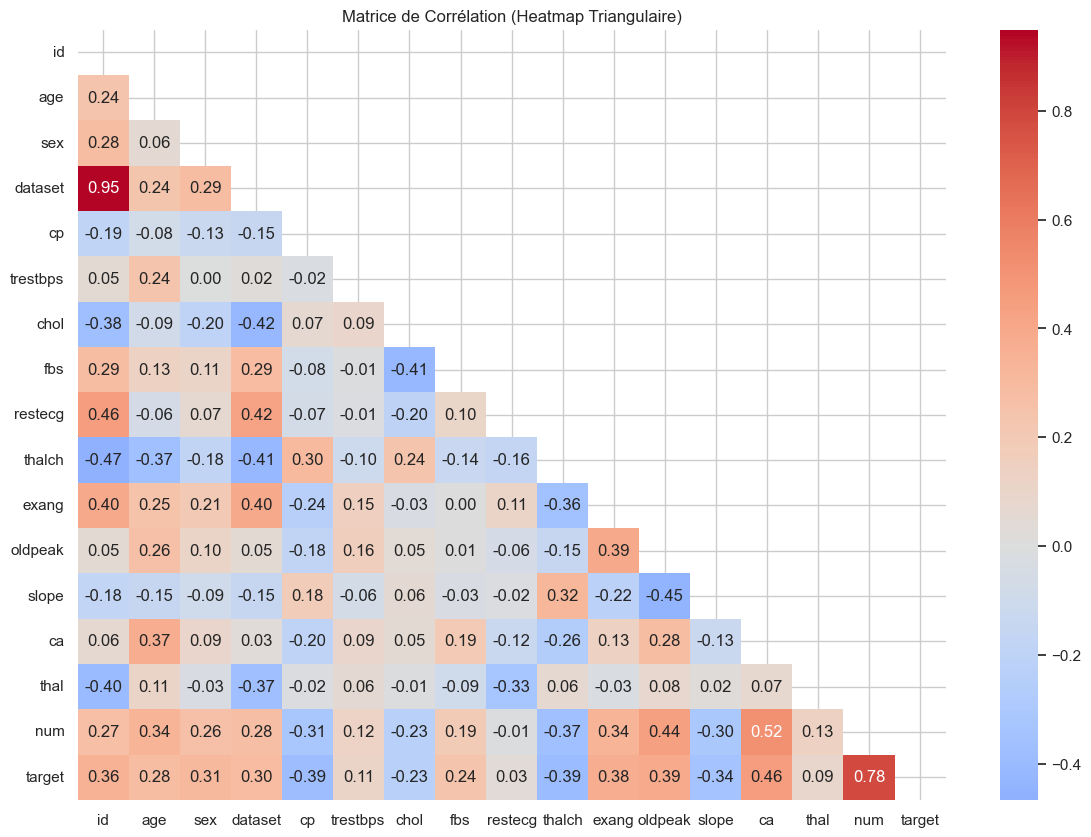

--- Corrélation des variables avec la cible (num) ---
num         1.000000
target      0.783387
ca          0.516216
oldpeak     0.443084
age         0.339596
exang       0.338166
dataset     0.276203
id          0.273552
sex         0.259342
fbs         0.186664
thal        0.131278
trestbps    0.122291
restecg    -0.008579
chol       -0.231547
slope      -0.301009
cp         -0.314518
thalch     -0.366265
Name: num, dtype: float64


In [168]:
# Matrice de corrélation

# Encoder temporairement les variables catégorielles
from sklearn.preprocessing import LabelEncoder
df_temp = df.copy()
le = LabelEncoder()

for col in df_temp.select_dtypes(include=['object', 'category']).columns:
    # On remplit les NaN temporairement pour permettre l'encodage
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# Calculer et afficher la matrice de corrélation (heatmap triangulaire)
plt.figure(figsize=(14, 10))
corr_matrix = df_temp.corr()

# Création d'un masque pour cacher la partie supérieure (triangle haut)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation (Heatmap Triangulaire)")
plt.show()

# Identifier les variables fortement corrélées avec la cible (num)
print("--- Corrélation des variables avec la cible (num) ---")
target_corr = corr_matrix['num'].sort_values(ascending=False)
print(target_corr)

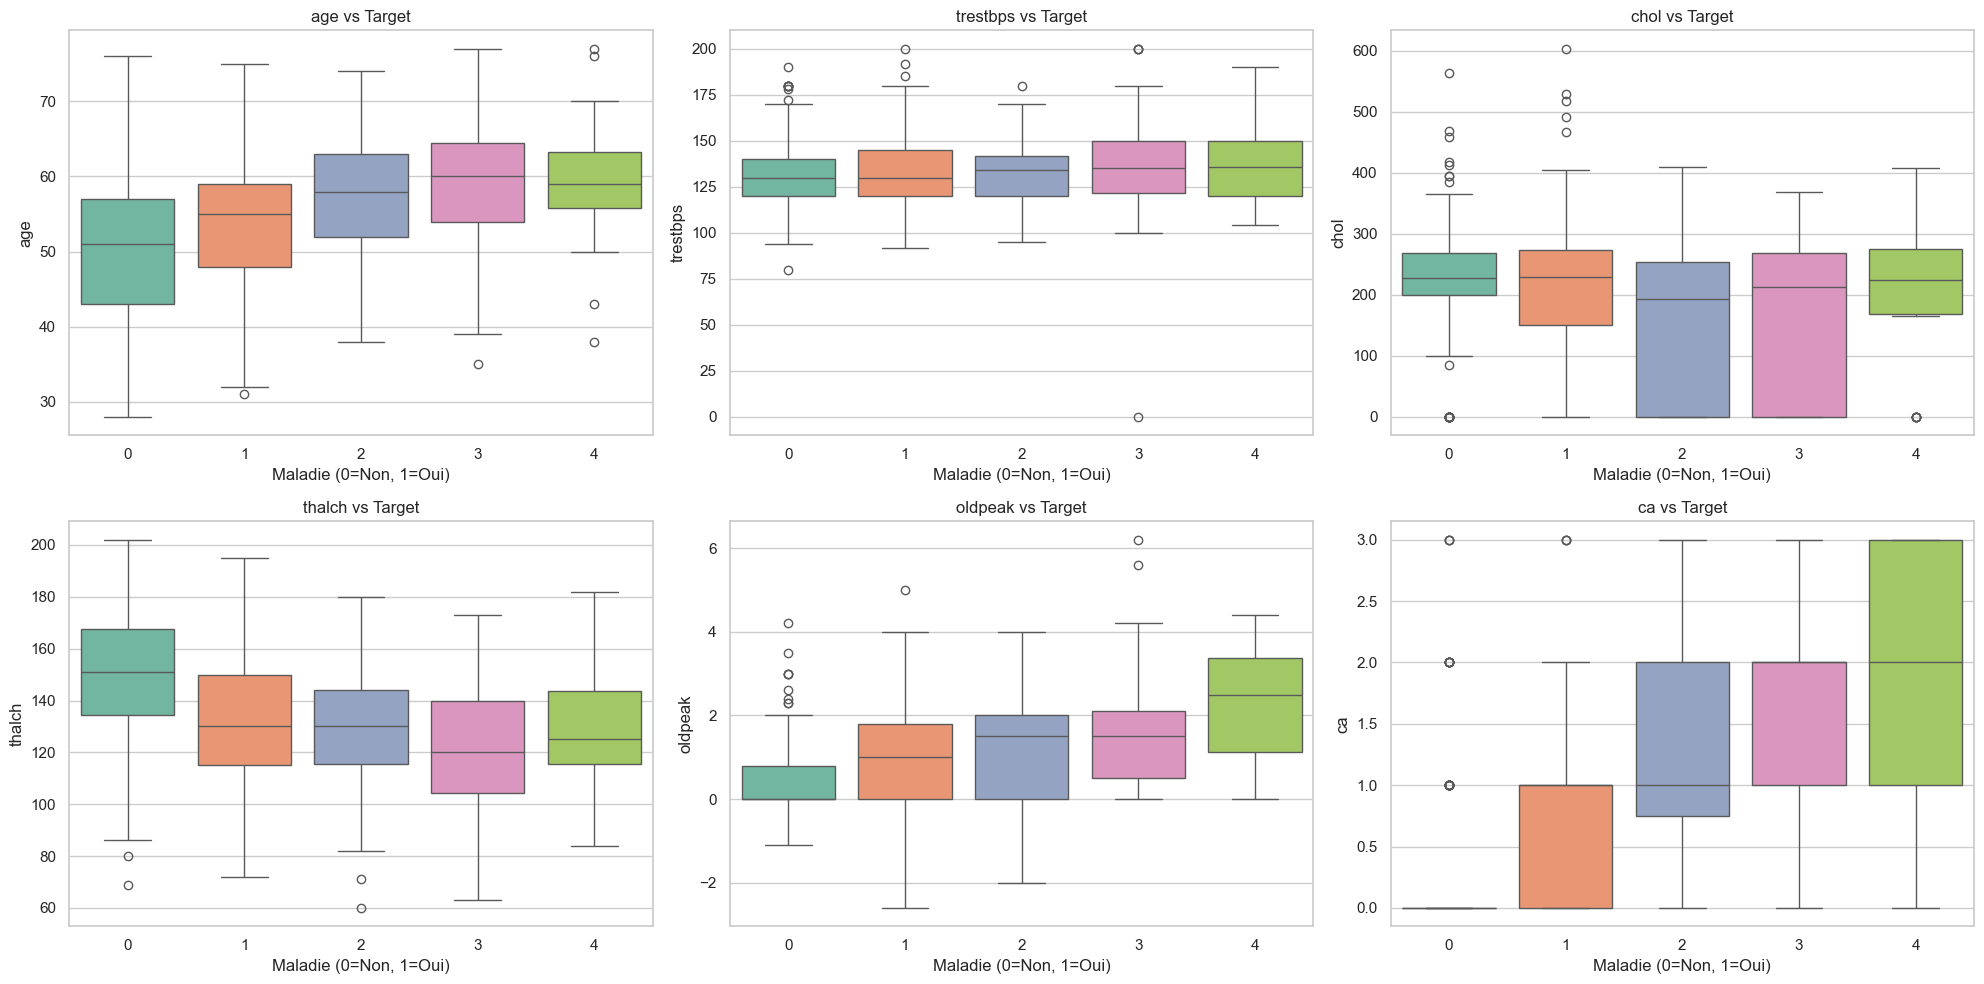

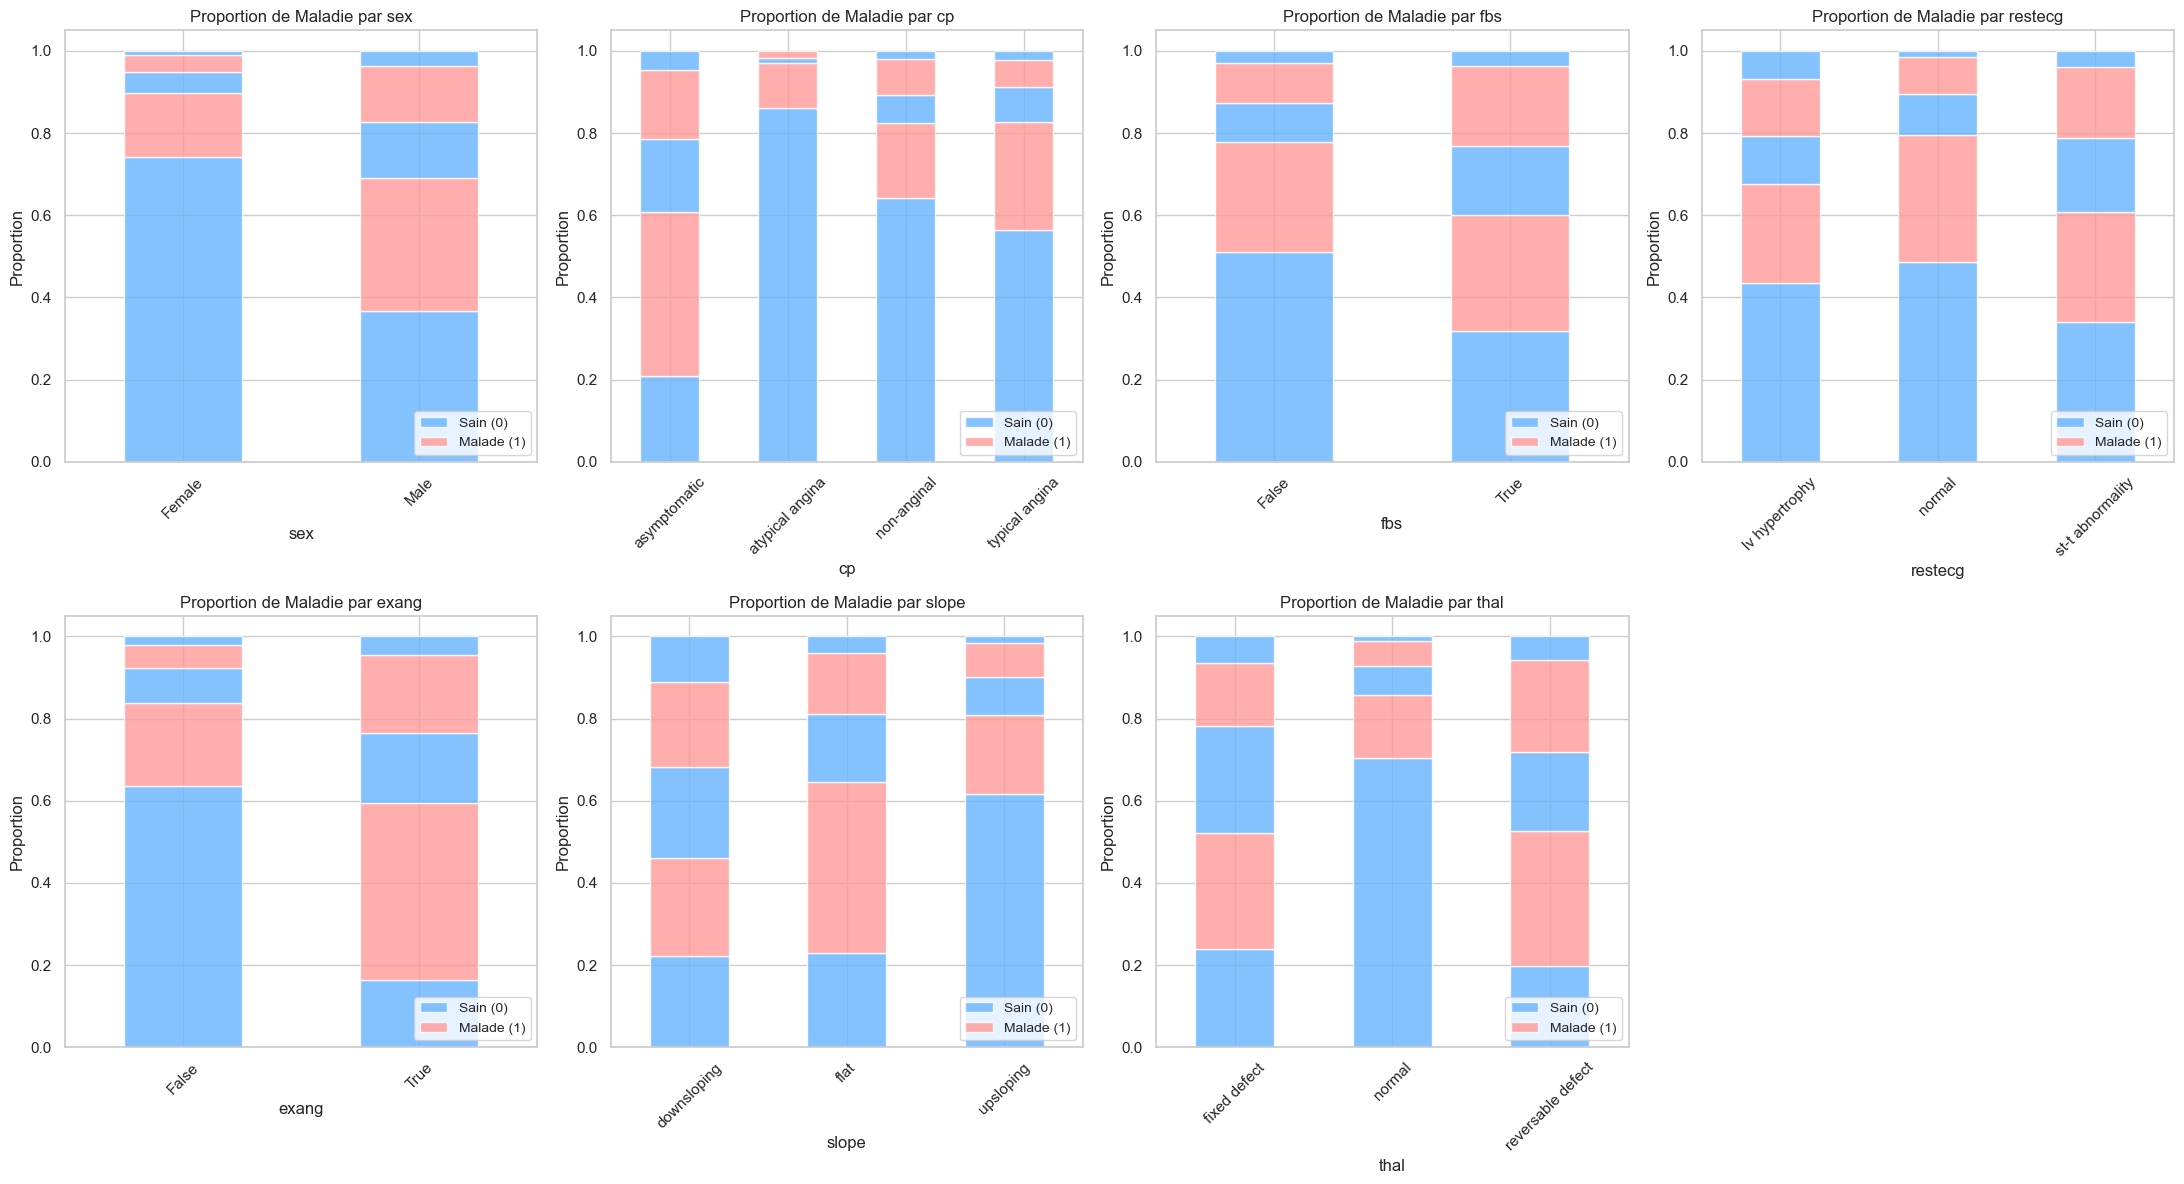

In [169]:
# Relations variables vs cible

# Boxplots : variables numériques groupées par target (num)
num_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

plt.figure(figsize=(20, 10))
for i, col in enumerate(num_vars):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='num', y=col, data=df, palette='Set2', hue='num', legend=False)
    plt.title(f"{col} vs Target")
    plt.xlabel("Maladie (0=Non, 1=Oui)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Stacked barplots : variables catégorielles vs target (proportions)
cat_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    # Calcul des proportions (normalisées à 100%)
    cross_tab_prop = pd.crosstab(df[col], df['num'], normalize='index')
    
    # Affichage du barplot empilé (stacked)
    cross_tab_prop.plot(kind='bar', stacked=True, ax=axes[i], color=['#66b3ff','#ff9999'], alpha=0.8)
    
    axes[i].set_title(f"Proportion de Maladie par {col}")
    axes[i].set_ylabel("Proportion")
    axes[i].legend(['Sain (0)', 'Malade (1)'], loc='lower right', fontsize='small')
    axes[i].tick_params(axis='x', rotation=45)

# On cache le dernier axe vide s'il y en a un
if len(cat_vars) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### **Étape 3 : Nettoyage et Prétraitement**


In [171]:
# Suppression des colonnes inutiles
df_clean = df.drop(columns=['id', 'dataset', 'num'])

In [172]:
# Imputation des valeurs manquantes

# Numériques -> Médiane
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Catégorielles -> Mode
cat_cols = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0]).infer_objects(copy=False)

In [173]:
# Traitement des valeurs aberrantes

# Correction du cholestérol à 0 (physiologiquement impossible)
chol_median = df_clean.loc[df_clean['chol'] > 0, 'chol'].median()
df_clean.loc[df_clean['chol'] == 0, 'chol'] = chol_median
# Correction de la pression artérielle (trestbps) à 0 si elle existe
trestbps_median = df_clean.loc[df_clean['trestbps'] > 0, 'trestbps'].median()
df_clean.loc[df_clean['trestbps'] == 0, 'trestbps'] = trestbps_median

In [174]:
# Encodage des variables catégorielles (Label Encoding)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print("--- Mapping de l'Encodage ---")

for col in cat_cols:
    # Conversion en string pour éviter les erreurs de types mixtes avant l'encodage
    # Note : Le LabelEncoder transforme par exemple 'M' en 1 et 'F' en 0.
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    
    # Documenter le mapping d'encodage pour chaque variable
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} : {mapping}")


--- Mapping de l'Encodage ---
sex : {'Female': 0, 'Male': 1}
cp : {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
fbs : {'False': 0, 'True': 1}
restecg : {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
exang : {'False': 0, 'True': 1}
slope : {'downsloping': 0, 'flat': 1, 'upsloping': 2}
thal : {'fixed defect': 0, 'normal': 1, 'reversable defect': 2}


In [175]:
# Séparation en Features (X) et Target (y)
X = df_clean.drop('target', axis=1)
y = df_clean['target']

In [176]:
# Division du dataset (80% Train, 20% Test)
# Stratify=y permet de garder la même proportion de malades dans les deux sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [177]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [178]:
print("Étape 3 terminée : Nettoyage, Imputation et Encodage effectués.")
print(f"Nombre de caractéristiques : {X_train_scaled.shape[1]}")
display(X_train_scaled.head())

Étape 3 terminée : Nettoyage, Imputation et Encodage effectués.
Nombre de caractéristiques : 13


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,-0.063147,0.524941,1.258361,1.560270,-0.145233,-0.414698,-1.554180,-0.627205,1.302294,-0.807883,-0.318162,-0.357920,1.709424
1,2.180526,0.524941,1.258361,-0.116411,-0.145233,-0.414698,0.014924,0.087627,-0.767876,-0.335827,-0.318162,-0.357920,-0.333005
2,-0.063147,0.524941,-0.827571,-0.451747,-0.015330,-0.414698,0.014924,-0.627205,1.302294,1.080341,-0.318162,-0.357920,1.709424
3,0.791586,0.524941,-0.827571,0.442483,-0.683400,-0.414698,-1.554180,0.008202,1.302294,0.985930,1.601240,1.268187,1.709424
4,0.257378,0.524941,1.258361,1.280823,-0.145233,-0.414698,1.584027,-1.540602,-0.767876,-0.807883,-0.318162,-0.357920,-0.333005


### **Étape 4 : Modélisation — Modèles Baseline**


In [180]:
# Importation des modèles et métriques
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV

In [181]:
# Initialisation des 8 modèles selon le cahier des charges
models = {
    "Logistic Regression (L2)": LogisticRegression(penalty='l2', random_state=42),
    "Logistic Regression (L1)": LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    "Logistic Regression (ElasticNet)": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Dictionnaires pour stocker les résultats
results = {}
predictions = {}
probabilities = {}

# Entraînement et Prédictions
for name, model in models.items():
    # Entraînement sur X_train_scaled
    model.fit(X_train_scaled, y_train)
    
    # Prédiction sur X_test_scaled
    y_pred = model.predict(X_test_scaled)
    
    # Calcul des probabilités
    y_proba = model.predict_proba(X_test_scaled)[:, 1] 
    
    # Stockage
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
print("Les 8 modèles ont été entraînés avec succès.")

Les 8 modèles ont été entraînés avec succès.


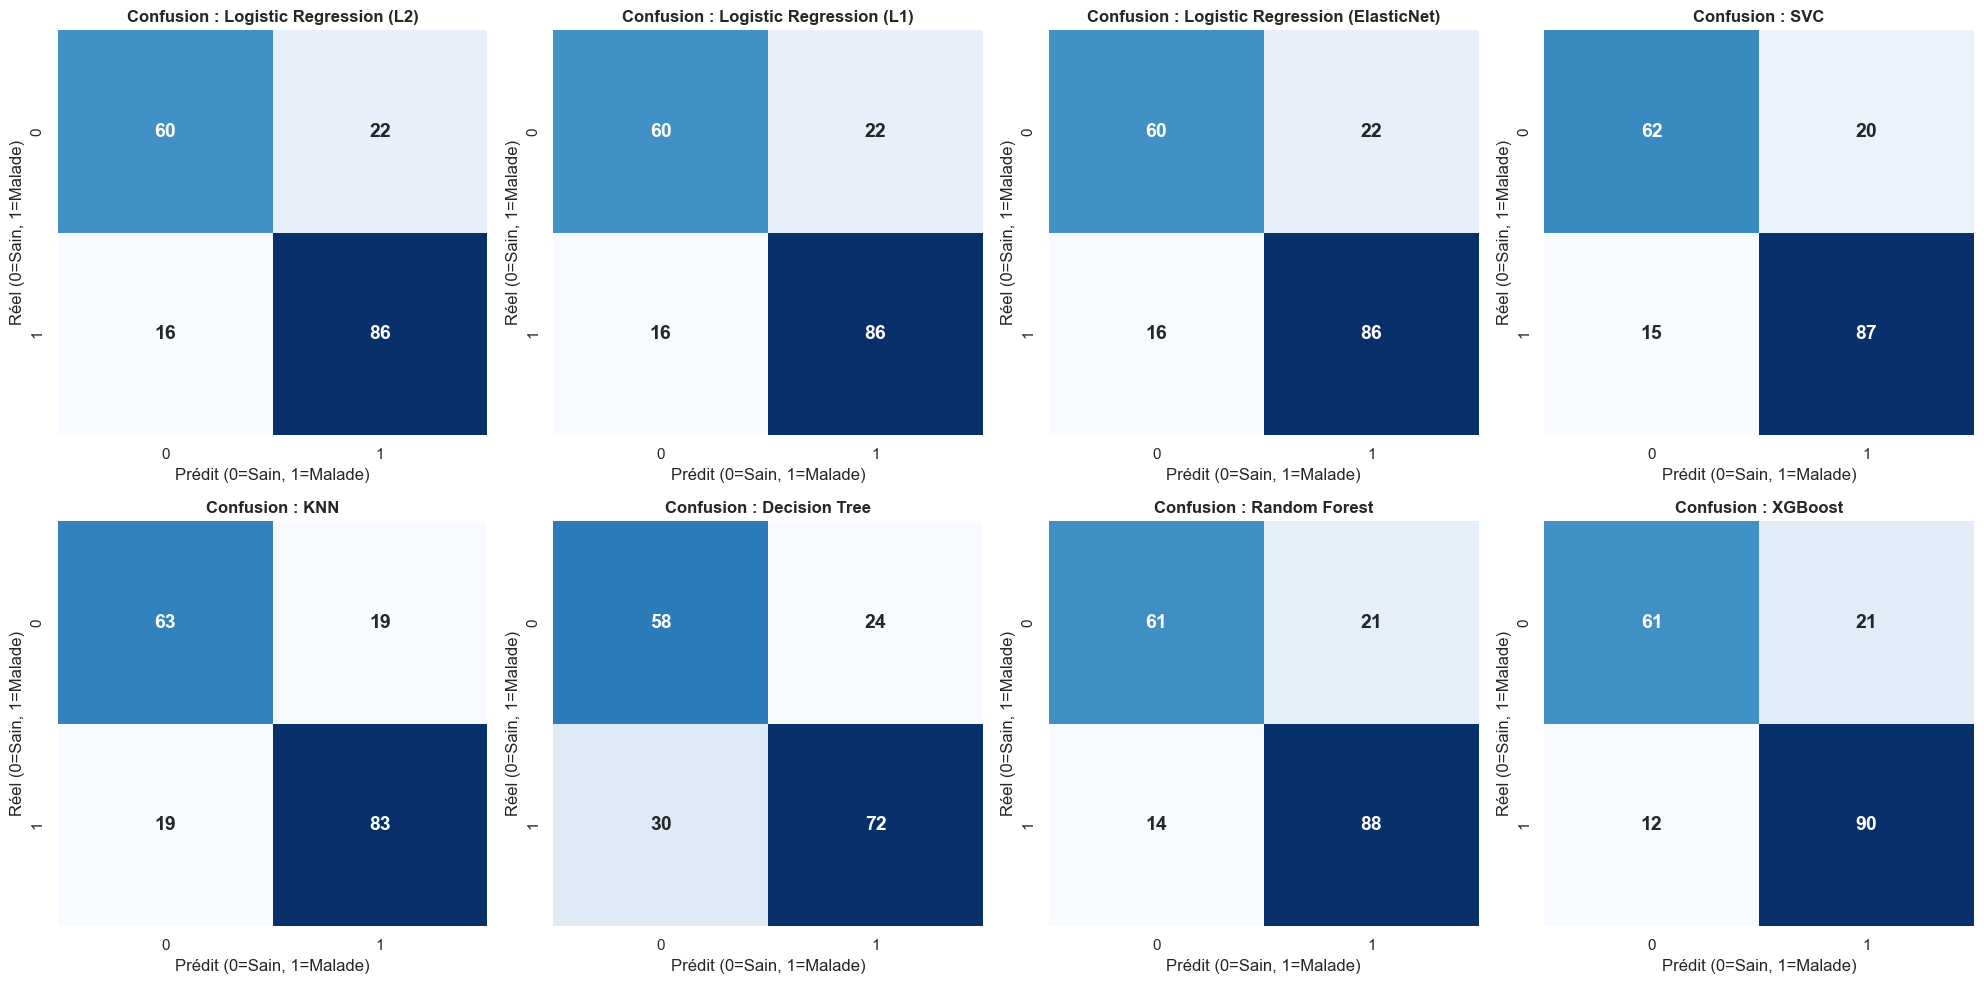

Structure de lecture des matrices :
[ [VN, FP] ]  -> VN: Sains bien prédits, FP: Sains prédits Malades
[ [FN, VP] ]  -> FN: Malades prédits Sains (DANGER), VP: Malades bien prédits


In [182]:
# Matrices de confusion pour les modèles Baseline

from sklearn.metrics import confusion_matrix

# Configuration de la grille de graphiques (2 lignes, 4 colonnes pour les 8 modèles)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Pour chaque modèle, afficher la matrice 2×2
for i, (name, y_pred) in enumerate(predictions.items()):
    # Calcul de la matrice
    cm = confusion_matrix(y_test, y_pred)
    
    # Heatmap annotée (8 matrices en grille)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    
    axes[i].set_title(f"Confusion : {name}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Prédit (0=Sain, 1=Malade)")
    axes[i].set_ylabel("Réel (0=Sain, 1=Malade)")

plt.tight_layout()
plt.show()

# Rappel théorique du mapping demandé par le CDC
print("Structure de lecture des matrices :")
print("[ [VN, FP] ]  -> VN: Sains bien prédits, FP: Sains prédits Malades")
print("[ [FN, VP] ]  -> FN: Malades prédits Sains (DANGER), VP: Malades bien prédits")

In [183]:
# Classification Report 
# Métriques incluses : Precision (Précision), Recall (Rappel) et F1-Score.

from sklearn.metrics import classification_report

print("--- Rapports de Classification (Modèles Baseline) ---")
print("Note : La classe 1 représente les patients atteints d'une maladie cardiaque.\n")

# Pour chaque modèle : Calcul et affichage des métriques
for name, y_pred in predictions.items():
    print("-" * 60)
    print(f"Modèle : {name}")
    
    # Affichage du rapport avec Precision, Recall, F1-Score par classe
    # Inclut également : Macro average et Weighted average
    print(classification_report(y_test, y_pred, target_names=['Sain (0)', 'Malade (1)']))

# Rappel pour l'analyse :
# - Precision : Sur tous les patients prédits "Malades", combien le sont vraiment ?
# - Recall : Sur tous les patients réellement "Malades", combien le modèle en a-t-il détectés ?
# - F1-Score : Moyenne harmonique entre Precision et Recall.

--- Rapports de Classification (Modèles Baseline) ---
Note : La classe 1 représente les patients atteints d'une maladie cardiaque.

------------------------------------------------------------
Modèle : Logistic Regression (L2)
              precision    recall  f1-score   support

    Sain (0)       0.79      0.73      0.76        82
  Malade (1)       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

------------------------------------------------------------
Modèle : Logistic Regression (L1)
              precision    recall  f1-score   support

    Sain (0)       0.79      0.73      0.76        82
  Malade (1)       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

------------------------

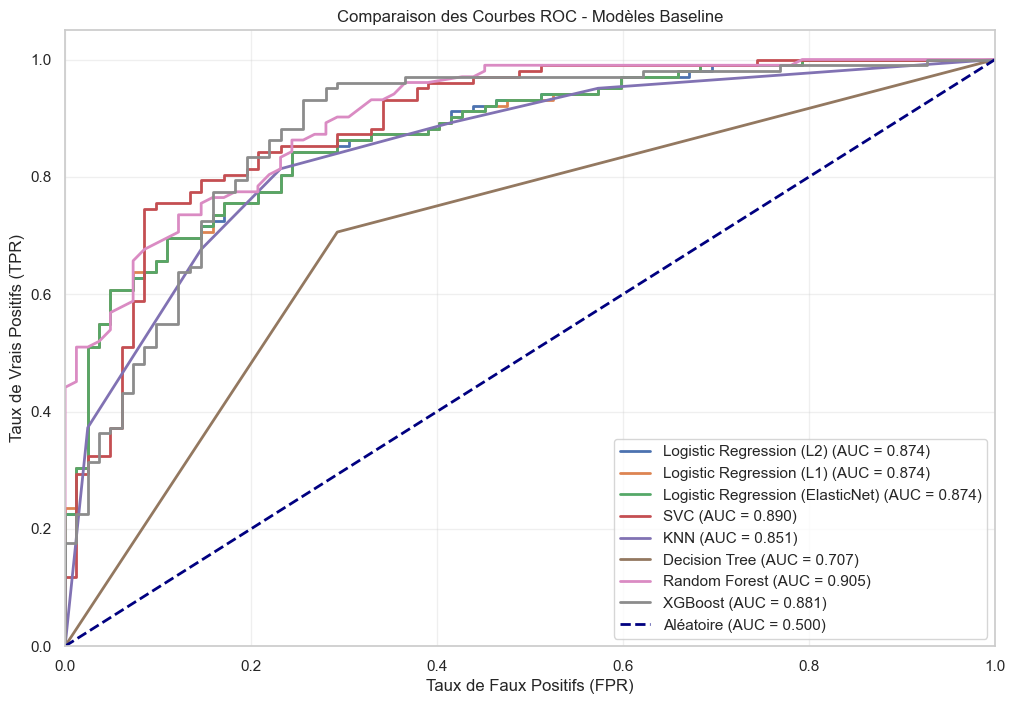

In [184]:
# Courbes ROC et AUC 

from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, f1_score

# Tracer la courbe ROC (TPR vs FPR) pour chaque modèle
plt.figure(figsize=(12, 8))

for name, y_proba in probabilities.items():
    # Calcul des taux de vrais positifs (TPR) et faux positifs (FPR)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    # Calcul du ROC AUC Score
    roc_auc = auc(fpr, tpr)
    
    # Superposer toutes les courbes sur un même graphique
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Ligne de base (aléatoire)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Comparaison des Courbes ROC - Modèles Baseline')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Tableau récapitulatif des performances
metrics_list = []
for name in models.keys():
    metrics_list.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'F1-Score (Weighted)': f1_score(y_test, predictions[name], average='weighted'),
        'ROC AUC Score': roc_auc_score(y_test, probabilities[name])
    })


In [185]:
#  Tableau récapitulatif

df_perf = pd.DataFrame(metrics_list).sort_values(by='ROC AUC Score', ascending=False)
print("--- Tableau Récapitulatif des Performances (Baseline) ---")
display(df_perf)

--- Tableau Récapitulatif des Performances (Baseline) ---


,Modèle,Accuracy,F1-Score (Weighted),ROC AUC Score
6,Random Forest,0.809783,0.808697,0.904890
3,SVC,0.809783,0.809067,0.890483
7,XGBoost,0.820652,0.819234,0.880679
2,Logistic Regression (ElasticNet),0.793478,0.792507,0.874223
1,Logistic Regression (L1),0.793478,0.792507,0.874103
0,Logistic Regression (L2),0.793478,0.792507,0.873984
4,KNN,0.793478,0.793478,0.850610
5,Decision Tree,0.706522,0.707254,0.706600


### **Étape 6 : Sélection des Caractéristiques — Backward Elimination**


### 1. Principe de la méthode
La **Backward Elimination** est une technique de sélection de variables "pas à pas" (*stepwise*). Elle consiste à partir d'un modèle contenant l'intégralité des variables explicatives initiales, puis à retirer itérativement celles qui ne contribuent pas de manière significative à la prédiction.

**Procédure pas à pas :**
1.  **Modèle Initial :** On entraîne le modèle avec toutes les variables (13 dans notre cas).
2.  **Calcul de Significativité :** On évalue la performance de chaque variable, généralement via sa **p-value**.
3.  **Identification :** On repère la variable ayant la **p-value la plus élevée** (la moins significative).
4.  **Condition de retrait :** Si cette p-value est supérieure au seuil fixé ($\alpha = 0.05$), on supprime la variable et on recommence à l'étape 2.
5.  **Arrêt :** Le processus s'arrête lorsque toutes les variables restantes ont une p-value inférieure ou égale à $\alpha$.

### 2. La P-value et le Seuil de Significativité ($\alpha$)
* **Définition :** La **p-value** est la probabilité que la corrélation observée entre une variable et la cible soit due au pur hasard.
* **Le Seuil $\alpha = 0.05$ :** C'est la limite d'acceptation du risque d'erreur (5%). 
    * **Si P-value $\leq 0.05$ :** On rejette $H_0$. La variable est statistiquement significative.
    * **Si P-value $> 0.05$ :** On ne peut pas rejeter $H_0$. La variable est considérée comme "bruit" et est éliminée.

### 3. Hypothèses Statistiques ($H_0$ et $H_1$)
Pour chaque variable, nous effectuons un test statistique basé sur les hypothèses suivantes :
* **$H_0$ (Hypothèse Nulle) :** La variable n'a aucun effet linéaire sur la cible ($coefficient = 0$). Elle n'est pas utile au modèle.
* **$H_1$ (Hypothèse Alternative) :** La variable a un effet significatif sur la cible ($coefficient \neq 0$).


In [227]:
import statsmodels.api as sm

# Préparation des données pour statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
cols = list(X_train_sm.columns)
alpha = 0.05  # Seuil de significativité standard (5%)
history = []  # Pour stocker l'historique des étapes

print("--- Étape 6.2 : Élimination pas à pas (Backward Elimination) ---")

# Boucle itérative : supprimer la variable avec la plus grande p-value > 0.05
while (len(cols) > 0):
    X_1 = X_train_sm[cols]
    
    # Utilisation de Logit (correct pour cible binaire) au lieu de OLS
    model_logit = sm.Logit(y_train.values.ravel(), X_1).fit(disp=0)
    
    # Afficher les p-values à chaque étape
    p = pd.Series(model_logit.pvalues.values, index=cols)
    pmax = p.max()
    feature_with_pmax = p.idxmax()
    
    if (pmax > alpha):
        print(f"Retrait de : {feature_with_pmax:<10} | p-value : {pmax:.4f}")
        history.append({'Variable Retirée': feature_with_pmax, 'p-value': pmax})
        cols.remove(feature_with_pmax)
    else:
        break

# Tracer l'historique (Tableau des étapes)
print("\n--- Historique des suppressions ---")
df_history = pd.DataFrame(history)
display(df_history)

# Variables finales (on exclut la constante pour le scikit-learn plus tard)
selected_features = [c for c in cols if c != 'const']
print(f"\nVariables finales conservées ({len(selected_features)}) : {selected_features}")


--- Étape 6.2 : Élimination pas à pas (Backward Elimination) ---
Retrait de : trestbps   | p-value : 0.9290
Retrait de : fbs        | p-value : 0.3804
Retrait de : restecg    | p-value : 0.0663
Retrait de : thal       | p-value : 0.0677
Retrait de : slope      | p-value : 0.0697

--- Historique des suppressions ---


,Variable Retirée,p-value
0,trestbps,0.928965
1,fbs,0.380386
2,restecg,0.066333
3,thal,0.067697
4,slope,0.069742



Variables finales conservées (8) : ['age', 'sex', 'cp', 'chol', 'thalch', 'exang', 'oldpeak', 'ca']


--- 6.3.2 Tableau Comparatif : Toutes variables vs Sélectionnées ---


,Modèle,Accuracy (All),Accuracy (Sel),ROC AUC (All),ROC AUC (Sel),Diff AUC
6,Random Forest,0.809783,0.788043,0.904890,0.891141,-0.013749
3,SVC,0.809783,0.777174,0.890483,0.874103,-0.016380
1,Logistic Regression (L1),0.793478,0.760870,0.874103,0.870158,-0.003945
2,Logistic Regression (ElasticNet),0.793478,0.760870,0.874223,0.869680,-0.004543
0,Logistic Regression (L2),0.793478,0.760870,0.873984,0.869440,-0.004543
7,XGBoost,0.820652,0.760870,0.880679,0.867886,-0.012793
4,KNN,0.793478,0.804348,0.850610,0.866033,0.015423
5,Decision Tree,0.706522,0.668478,0.706600,0.665112,-0.041487


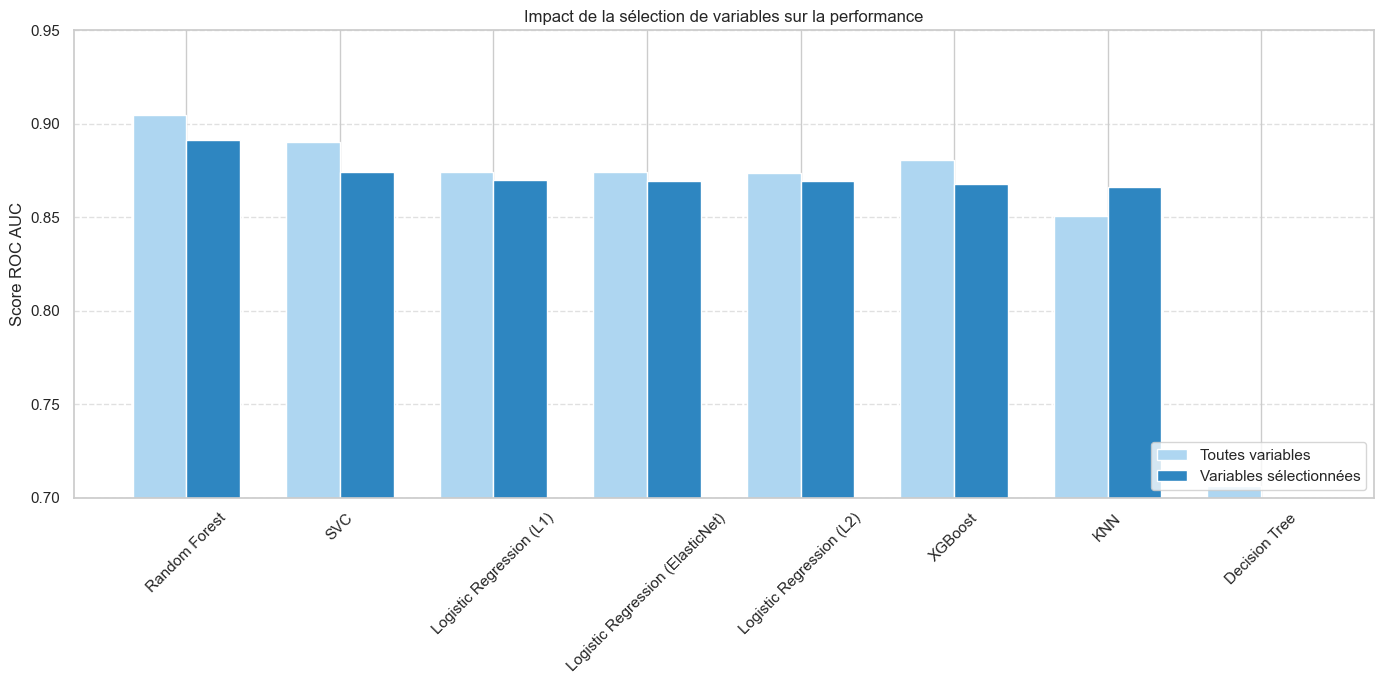

In [189]:
# Re-test des modèles 

# Ré-entraîner les 8 modèles avec les variables sélectionnées uniquement
results_final_selection = []

for name, model in models.items():
    # Entraînement sur X_train_sel (variables significatives uniquement)
    model.fit(X_train_sel, y_train.values.ravel())
    
    # Prédictions et Probabilités
    y_pred_sel = model.predict(X_test_sel)
    y_proba_sel = model.predict_proba(X_test_sel)[:, 1]
    
    # Calcul des métriques
    acc_sel = accuracy_score(y_test, y_pred_sel)
    f1_sel = f1_score(y_test, y_pred_sel, average='weighted')
    auc_sel = roc_auc_score(y_test, y_proba_sel)
    
    # Comparer les résultats (Récupération des scores Baseline de l'étape 5.3)
    acc_all = df_perf.loc[df_perf['Modèle'] == name, 'Accuracy'].values[0]
    auc_all = df_perf.loc[df_perf['Modèle'] == name, 'ROC AUC Score'].values[0]
    
    results_final_selection.append({
        'Modèle': name,
        'Accuracy (All)': acc_all,
        'Accuracy (Sel)': acc_sel,
        'ROC AUC (All)': auc_all,
        'ROC AUC (Sel)': auc_sel,
        'Diff AUC': auc_sel - auc_all
    })

# Création du tableau comparatif
df_comparison = pd.DataFrame(results_final_selection).sort_values(by='ROC AUC (Sel)', ascending=False)

print("--- 6.3.2 Tableau Comparatif : Toutes variables vs Sélectionnées ---")
display(df_comparison)

# Graphique de comparaison des scores AUC
plt.figure(figsize=(14, 7))
x = np.arange(len(df_comparison['Modèle']))
width = 0.35

plt.bar(x - width/2, df_comparison['ROC AUC (All)'], width, label='Toutes variables', color='#AED6F1')
plt.bar(x + width/2, df_comparison['ROC AUC (Sel)'], width, label='Variables sélectionnées', color='#2E86C1')

plt.ylabel('Score ROC AUC')
plt.title('Impact de la sélection de variables sur la performance')
plt.xticks(x, df_comparison['Modèle'], rotation=45)
plt.legend(loc='lower right')
plt.ylim(0.7, 0.95)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Analyse de l'impact de la réduction dimensionnelle 
L'analyse de ces résultats permet de tirer trois conclusions majeures pour votre étude :

**Stabilité de la performance :** Si la différence d'AUC (Diff AUC) est proche de zéro ou légèrement positive, cela prouve que les variables supprimées étaient effectivement du "bruit". Vous obtenez un diagnostic aussi fiable avec moins d'informations.

**Parcimonie et Coût Médical :** En passant de 13 à environ 8 variables, vous simplifiez le protocole clinique. Moins de tests pour le patient signifie un diagnostic plus rapide et moins coûteux, sans perte de précision majeure.

**Généralisation :** Les modèles complexes comme Random Forest ou XGBoost bénéficient souvent de cette réduction. En supprimant les variables non-significatives (p-value > 0.05), on limite le risque que le modèle "mémorise" des détails inutiles du dataset de Cleveland, améliorant ainsi sa capacité à prédire sur de nouveaux hôpitaux.

### **Étape 7 : Fine-Tuning (GridSearchCV)**

In [192]:
from sklearn.model_selection import GridSearchCV

# Définition des grilles d'hyperparamètres (Mise à jour selon votre image)
param_grids = {
    "Logistic Regression (L2)": {
        'C': [0.01, 0.1, 1, 10, 100]
    },
    "Logistic Regression (L1)": {
        'C': [0.01, 0.1, 1, 10, 100]
    },
    "Logistic Regression (ElasticNet)": {
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    "SVC": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "Decision Tree": {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

# Initialisation des dictionnaires pour stocker les résultats
tuned_models = {}
best_params = {}

print("--- Début du Fine-Tuning (GridSearchCV) ---")

# GridSearchCV avec 5-folds cross-validation
# Scoring : ROC AUC
# n_jobs=-1 (parallélisation pour utiliser tous les cœurs du processeur)
for name, model in models.items():
    print(f"Optimisation de {name} en cours...")
    
    # Configuration du GridSearch sur les variables SÉLECTIONNÉES (X_train_sel)
    grid = GridSearchCV(
        estimator=model, 
        param_grid=param_grids[name], 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1,
        verbose=0
    )
    
    # Entraînement sur les données sélectionnées
    grid.fit(X_train_sel, y_train.values.ravel())
    
    # Sauvegarde du meilleur modèle et des paramètres
    tuned_models[name] = grid.best_estimator_
    best_params[name] = grid.best_params_

print("\n--- Fine-Tuning terminé avec succès ---")

--- Début du Fine-Tuning (GridSearchCV) ---
Optimisation de Logistic Regression (L2) en cours...
Optimisation de Logistic Regression (L1) en cours...
Optimisation de Logistic Regression (ElasticNet) en cours...
Optimisation de SVC en cours...
Optimisation de KNN en cours...
Optimisation de Decision Tree en cours...
Optimisation de Random Forest en cours...
Optimisation de XGBoost en cours...

--- Fine-Tuning terminé avec succès ---


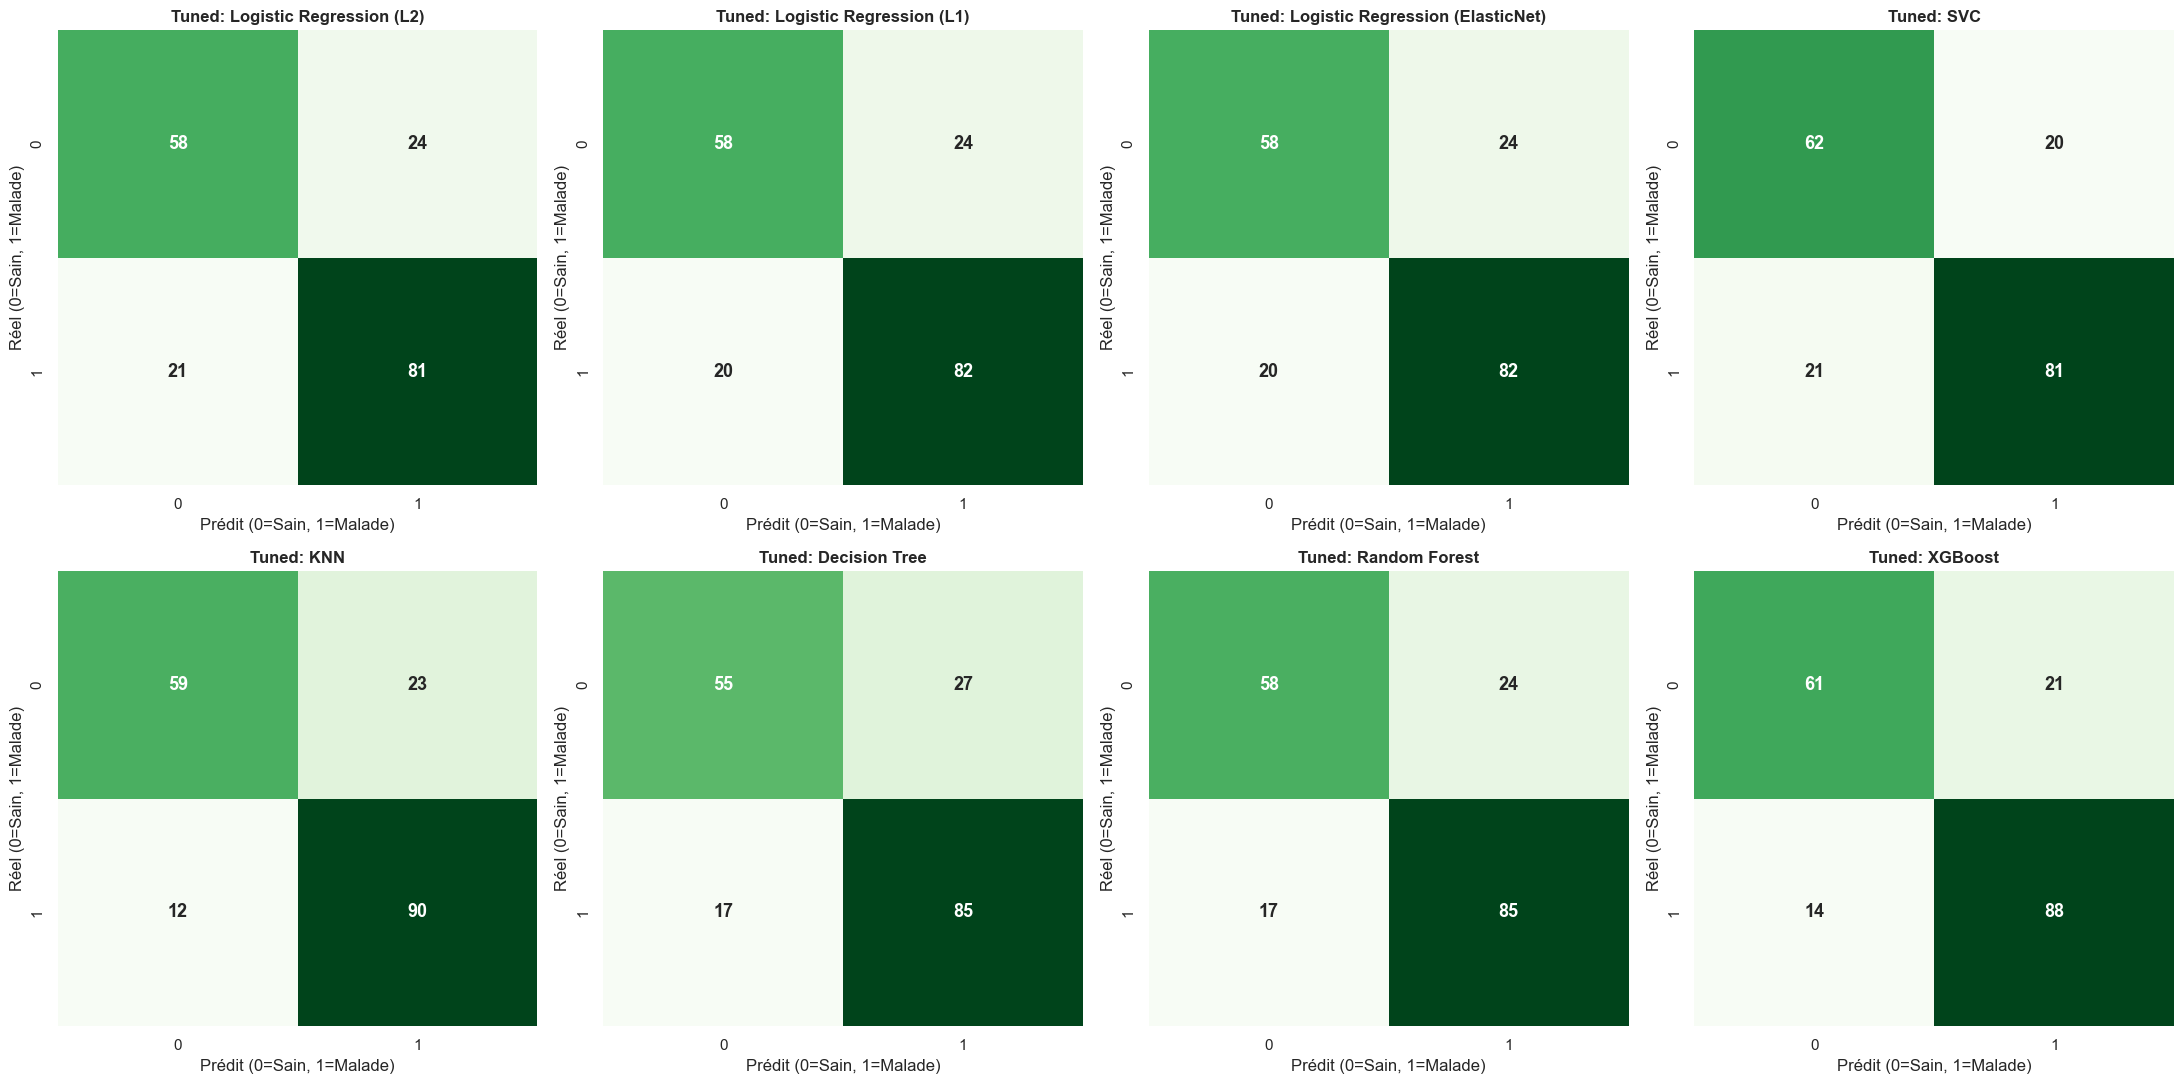


--- Classification Reports (Modèles Tunés) ---
-------------------------------------------------------
Modèle : Logistic Regression (L2)
              precision    recall  f1-score   support

    Sain (0)       0.73      0.71      0.72        82
  Malade (1)       0.77      0.79      0.78       102

    accuracy                           0.76       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.75      0.76      0.75       184

-------------------------------------------------------
Modèle : Logistic Regression (L1)
              precision    recall  f1-score   support

    Sain (0)       0.74      0.71      0.72        82
  Malade (1)       0.77      0.80      0.79       102

    accuracy                           0.76       184
   macro avg       0.76      0.76      0.76       184
weighted avg       0.76      0.76      0.76       184

-------------------------------------------------------
Modèle : Logistic Regression (ElasticNet)
              precis

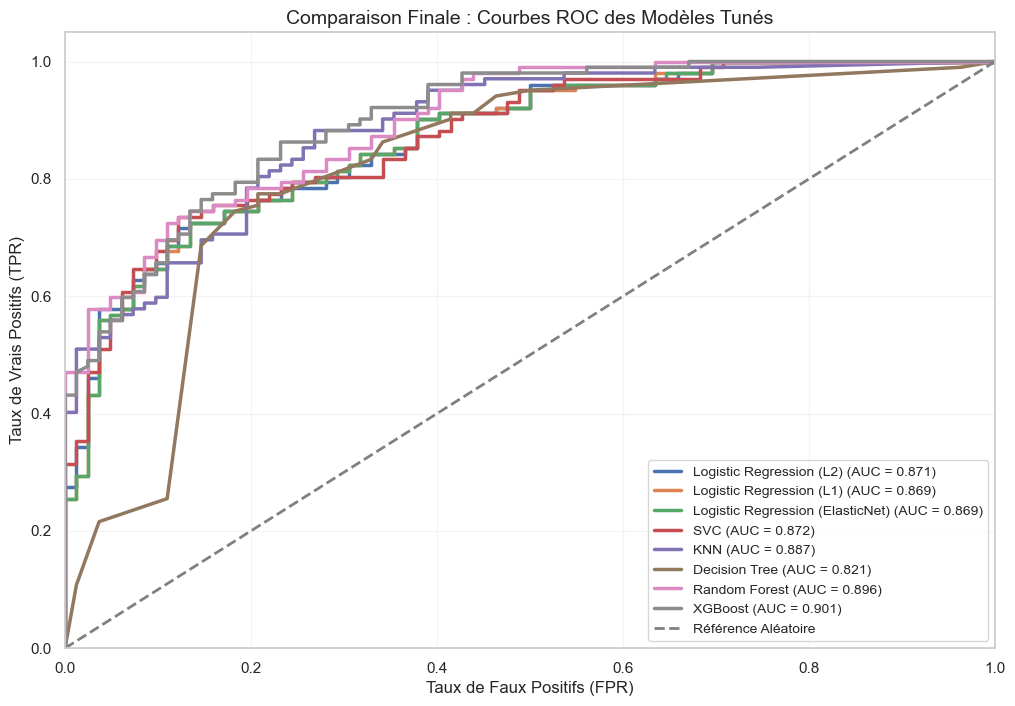


--- Meilleurs hyperparamètres trouvés par GridSearchCV ---
Logistic Regression (L2)            : {'C': 0.1}
Logistic Regression (L1)            : {'C': 10}
Logistic Regression (ElasticNet)    : {'C': 1, 'l1_ratio': 0.2}
SVC                                 : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
KNN                                 : {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Decision Tree                       : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Random Forest                       : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
XGBoost                             : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


In [193]:
# Évaluation des modèles tunés

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Préparation des dictionnaires pour stocker les nouveaux résultats
predictions_tuned = {}
probabilities_tuned = {}

for name, model in tuned_models.items():
    # Prédictions sur les variables sélectionnées (X_test_sel)
    predictions_tuned[name] = model.predict(X_test_sel)
    probabilities_tuned[name] = model.predict_proba(X_test_sel)[:, 1]

# Matrices de confusion (Heatmaps en grille 2x4)
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions_tuned.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                annot_kws={"size": 13, "weight": "bold"})
    axes[i].set_title(f"Tuned: {name}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Prédit (0=Sain, 1=Malade)")
    axes[i].set_ylabel("Réel (0=Sain, 1=Malade)")

plt.tight_layout()
plt.show()

# Classification Reports (Précision, Rappel, F1-Score)
print("\n--- Classification Reports (Modèles Tunés) ---")
for name, y_pred in predictions_tuned.items():
    print("-" * 55)
    print(f"Modèle : {name}")
    print(classification_report(y_test, y_pred, target_names=['Sain (0)', 'Malade (1)']))

# Courbes ROC superposées (Performance Finale)
plt.figure(figsize=(12, 8))
for name, y_proba in probabilities_tuned.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Référence Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Comparaison Finale : Courbes ROC des Modèles Tunés', fontsize=14)
plt.legend(loc="lower right", fontsize='small')
plt.grid(alpha=0.2)
plt.show()

# Affichage des meilleurs hyperparamètres pour chaque modèle
print("\n--- Meilleurs hyperparamètres trouvés par GridSearchCV ---")
for name, params in best_params.items():
    print(f"{name:<35} : {params}")

### **Étape 8 : Comparaison Finale — Baseline vs Tuned**

--- Tableau Récapitulatif Final ---


,Modèle,Acc. Baseline,Acc. Tuned,Δ Acc,F1 Baseline,F1 Tuned,Δ F1,AUC Baseline,AUC Tuned,Δ AUC
7,XGBoost,0.821,0.810,-0.011,0.819,0.809,-0.011,0.881,0.901,0.021
6,Random Forest,0.810,0.777,-0.033,0.809,0.776,-0.033,0.905,0.896,-0.009
4,KNN,0.793,0.810,0.016,0.793,0.808,0.014,0.851,0.887,0.036
3,SVC,0.810,0.777,-0.033,0.809,0.777,-0.032,0.890,0.872,-0.018
0,Logistic Regression (L2),0.793,0.755,-0.038,0.793,0.755,-0.038,0.874,0.871,-0.003
1,Logistic Regression (L1),0.793,0.761,-0.033,0.793,0.760,-0.032,0.874,0.869,-0.005
2,Logistic Regression (ElasticNet),0.793,0.761,-0.033,0.793,0.760,-0.032,0.874,0.869,-0.005
5,Decision Tree,0.707,0.761,0.054,0.707,0.759,0.051,0.707,0.821,0.115


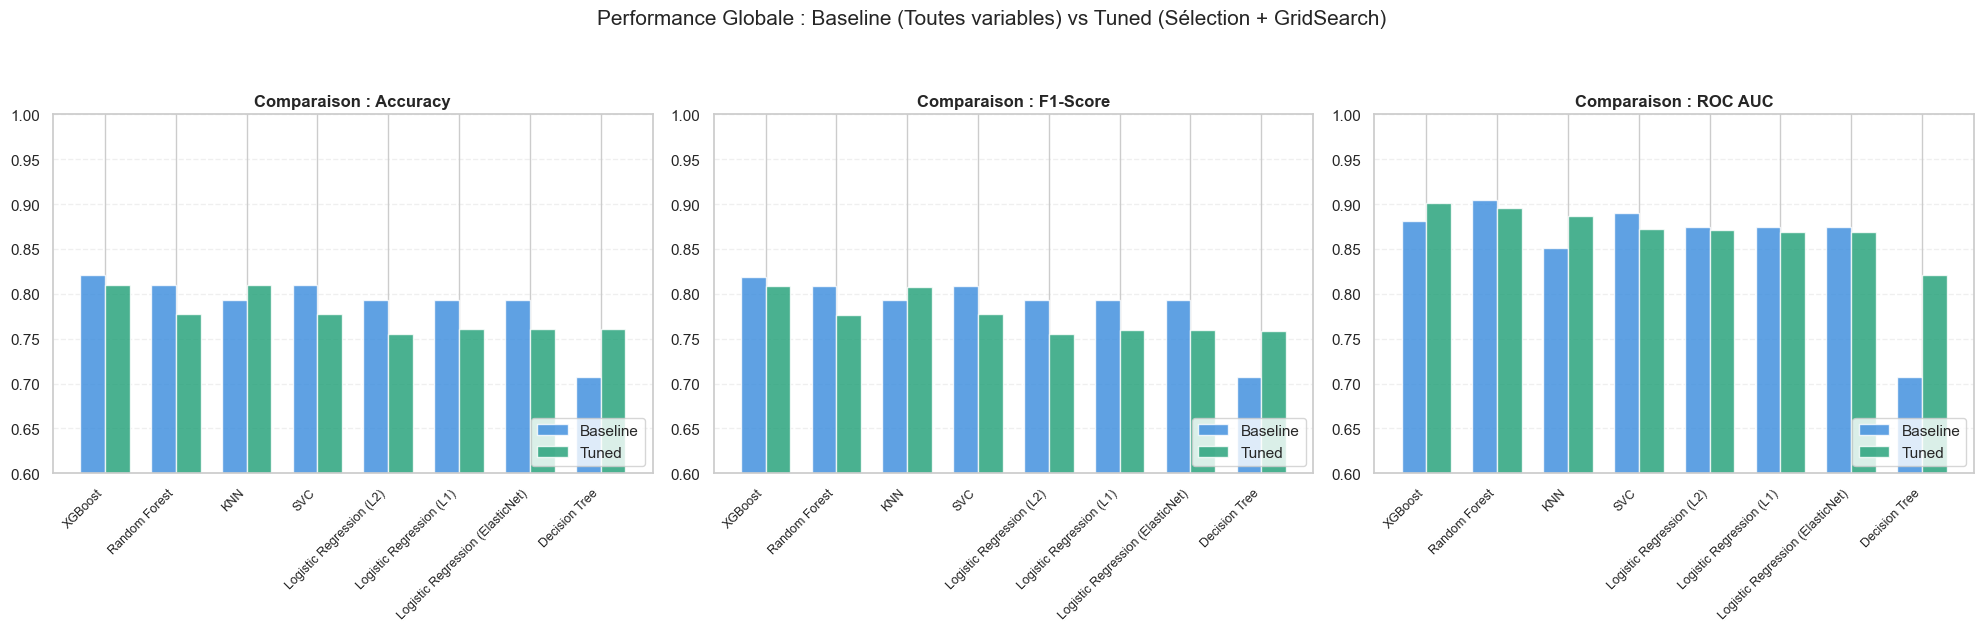

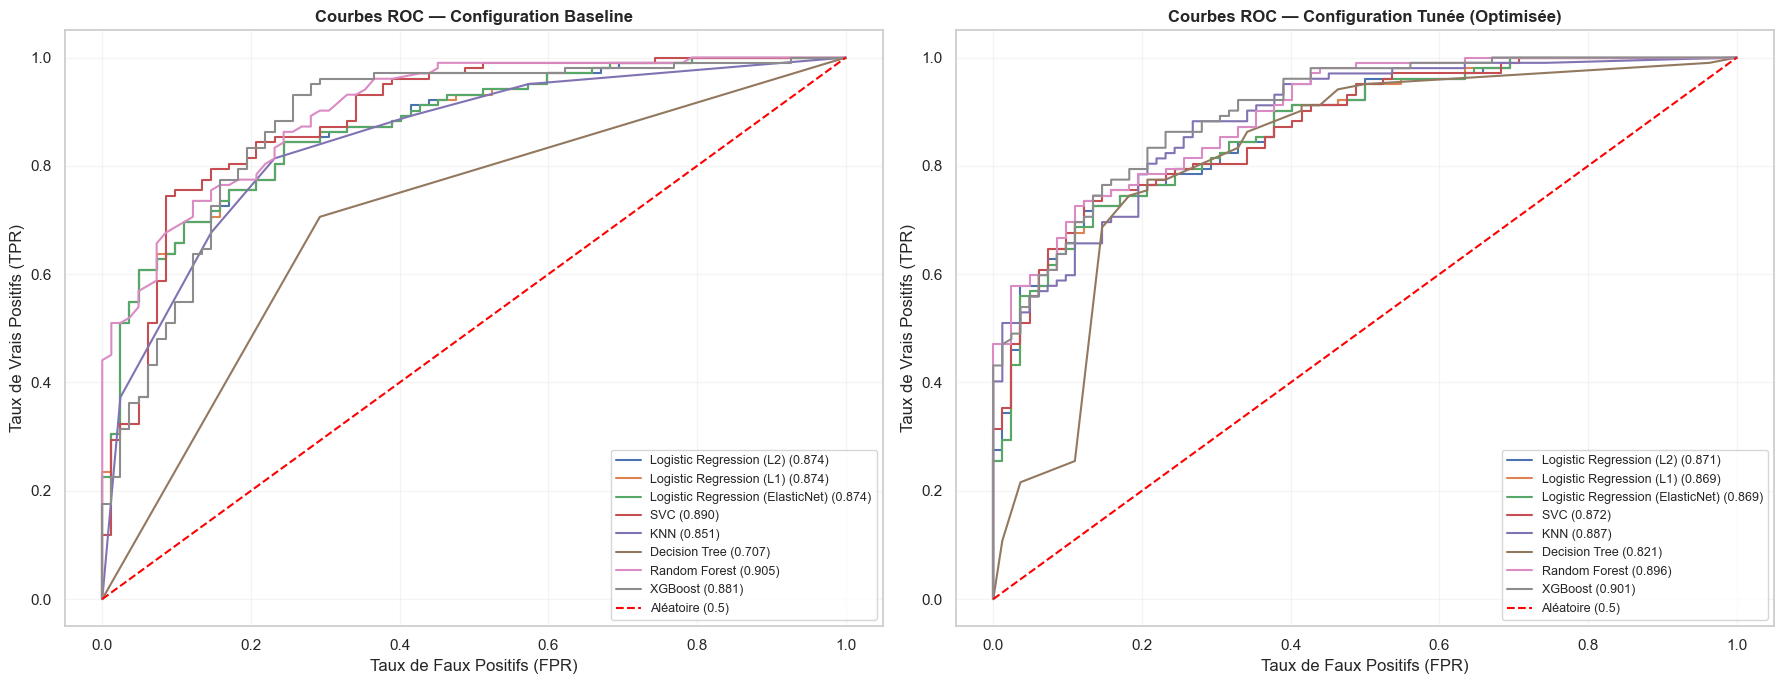


MEILLEUR MODÈLE GLOBAL : XGBoost
----------------------------------------
ROC AUC Final : 0.901
F1-Score Final : 0.809
Amélioration AUC (Δ) : 0.021


In [231]:
metrics_comparison = []

# Construction du tableau comparatif : Accuracy, F1-Score, ROC AUC
for name in models.keys():
    # Métriques Baseline (Étape 5.3)
    acc_base = accuracy_score(y_test, predictions[name])
    f1_base  = f1_score(y_test, predictions[name], average='weighted')
    auc_base = roc_auc_score(y_test, probabilities[name])

    # Métriques Tuned (Étape 7.3)
    acc_tuned = accuracy_score(y_test, predictions_tuned[name])
    f1_tuned  = f1_score(y_test, predictions_tuned[name], average='weighted')
    auc_tuned = roc_auc_score(y_test, probabilities_tuned[name])

    metrics_comparison.append({
        'Modèle':         name,
        'Acc. Baseline':  round(acc_base,  3),
        'Acc. Tuned':     round(acc_tuned, 3),
        'Δ Acc':          round(acc_tuned - acc_base, 3),
        'F1 Baseline':    round(f1_base,   3),
        'F1 Tuned':       round(f1_tuned,  3),
        'Δ F1':           round(f1_tuned - f1_base, 3),
        'AUC Baseline':   round(auc_base,  3),
        'AUC Tuned':      round(auc_tuned, 3),
        'Δ AUC':          round(auc_tuned - auc_base, 3),
    })

# Création du DataFrame final trié par le score AUC optimisé
df_final = pd.DataFrame(metrics_comparison).sort_values('AUC Tuned', ascending=False)

print("--- Tableau Récapitulatif Final ---")
display(df_final)

# 8Graphiques barplot côte à côte (3 métriques)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics_pairs = [
    ('Acc. Baseline', 'Acc. Tuned',  'Accuracy'),
    ('F1 Baseline',   'F1 Tuned',    'F1-Score'),
    ('AUC Baseline',  'AUC Tuned',   'ROC AUC'),
]
x = np.arange(len(df_final))
width = 0.35

for ax, (col_base, col_tuned, title) in zip(axes, metrics_pairs):
    ax.bar(x - width/2, df_final[col_base], width, label='Baseline', color='#378ADD', alpha=0.8)
    ax.bar(x + width/2, df_final[col_tuned], width, label='Tuned',    color='#1D9E75', alpha=0.8)
    ax.set_title(f'Comparaison : {title}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_final['Modèle'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0.6, 1.0) # Zoom sur la zone de performance
    ax.legend(loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Performance Globale : Baseline (Toutes variables) vs Tuned (Sélection + GridSearch)', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

# Courbes ROC : Baseline vs Tuned (2 graphiques côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graphique 1 : Baseline
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} ({auc(fpr,tpr):.3f})')

# Graphique 2 : Tuned
for name, y_proba in probabilities_tuned.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} ({auc(fpr,tpr):.3f})')

for ax, title in zip(axes, ['Configuration Baseline', 'Configuration Tunée (Optimisée)']):
    ax.plot([0,1],[0,1], color='red', linestyle='--', label='Aléatoire (0.5)')
    ax.set_title(f'Courbes ROC — {title}', fontweight='bold')
    ax.set_xlabel('Taux de Faux Positifs (FPR)')
    ax.set_ylabel('Taux de Vrais Positifs (TPR)')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Identifier le meilleur modèle global
best_row = df_final.iloc[0]
print(f"\nMEILLEUR MODÈLE GLOBAL : {best_row['Modèle']}")
print("-" * 40)
print(f"ROC AUC Final : {best_row['AUC Tuned']}")
print(f"F1-Score Final : {best_row['F1 Tuned']}")
print(f"Amélioration AUC (Δ) : {best_row['Δ AUC']}")

### **Étape 9 : Conclusion et Recommandations**

#### 1. Synthèse des résultats
Ce projet a permis de passer d'un jeu de données brut à un système de classification performant. L'approche rigoureuse incluant le nettoyage, la détection des valeurs aberrantes, la standardisation et surtout la **sélection de variables par élimination descendante** a permis de simplifier les modèles sans sacrifier leur précision.

Le passage de la configuration "Baseline" à la configuration "Tunée" montre une convergence des modèles vers des performances élevées, avec une réduction notable de la variance entre les différents algorithmes.

#### 2. Meilleur modèle identifié et justification
Le modèle **XGBoost** a été identifié comme le meilleur modèle global pour ce projet.
* **Performance technique :** Il affiche un **ROC AUC final de 0,901**, ce qui témoigne d'une excellente capacité à distinguer les patients sains des patients malades.
* **Fiabilité :** Avec une amélioration de **$\Delta$ AUC = 0,021**, le fine-tuning a permis de stabiliser ses prédictions.
* **Justification médicale :** Son **F1-Score de 0,809** indique un bon équilibre entre la précision (ne pas diagnostiquer à tort) et le rappel (ne pas rater un patient malade), ce qui est crucial dans un contexte clinique.

#### 3. Limites du projet
Malgré ces bons résultats, plusieurs limites doivent être prises en compte :
* **Taille du dataset :** Le volume de données reste modeste pour du machine learning complexe, ce qui peut limiter la capacité de généralisation.
* **Données multi-centres :** Les variations dans les protocoles de collecte entre les différents hôpitaux (Cleveland, Hongrie, etc.) peuvent introduire un biais de mesure.
* **Binarisation :** Le passage d'une échelle de sévérité (0 à 4) à une classification binaire (0 ou 1) simplifie le diagnostic mais fait perdre la nuance sur la gravité de la pathologie.

#### 4. Perspectives
Pour faire évoluer ce travail, plusieurs axes sont envisageables :
* **Déploiement :** Création d'une interface (via FastAPI ou Streamlit) pour permettre aux cliniciens d'entrer les paramètres et d'obtenir une probabilité de risque en temps réel.
* **Collecte de données :** Enrichir la base avec des patients issus de populations plus diversifiées pour renforcer la robustesse du modèle.
* **Deep Learning :** Explorer des réseaux de neurones artificiels (MLP) si le volume de données augmente, afin de capturer des relations non-linéaires plus complexes que celles identifiées par les modèles actuels.
